In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import os


In [2]:
INDEX_FUNDS = ["VFV.TO", "VSP.TO", "XUS.TO", "XIC.TO", "VCN.TO", "XIU.TO"]
INDEX_FUND_PERIOD = "5y"

In [41]:
def index_fund_data(tickets: list, period: str):
    data = {}
    for index_fund in tickets:
        try:
            response = yf.download(tickers=index_fund, period=period)
            if isinstance(response.columns, pd.MultiIndex):
                response.columns = response.columns.get_level_values(0)
            data[index_fund] = response
        except Exception as e:
            print(e)
    return data
        
    
    
data = index_fund_data(INDEX_FUNDS, INDEX_FUND_PERIOD)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [42]:
for key in data.keys():
    print(key)
    print(data[key].isnull().sum())
vfv = data["VFV.TO"]

VFV.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
VSP.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
XUS.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
XIC.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
VCN.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
XIU.TO
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [43]:
vfv.describe()
vfv.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-02,81.894852,82.847558,81.894852,82.847558,182400
2021-03-03,81.008171,82.423079,81.008171,82.423079,185600
2021-03-04,80.008324,81.244008,79.263138,80.904429,311900
2021-03-05,81.630745,81.725071,79.470652,81.036486,263500
2021-03-08,81.206261,82.347626,81.206261,82.064641,232800


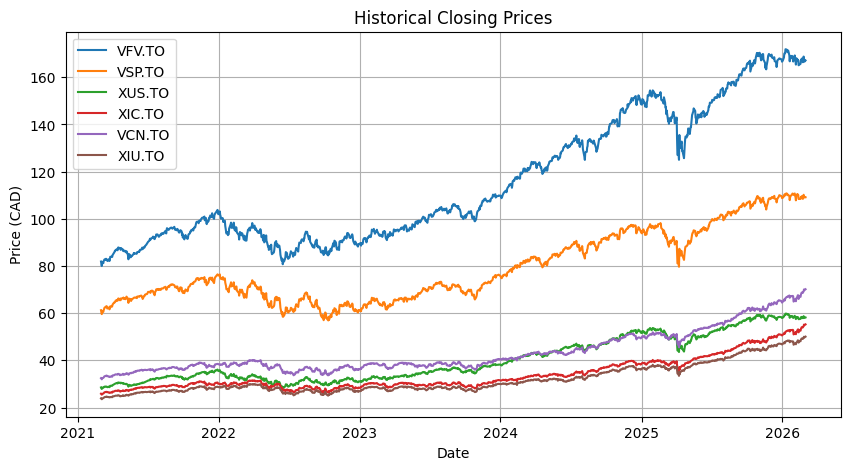

In [44]:
figure, axis = plt.subplots(figsize=(10, 5))

for ticker, df in data.items():
    axis.plot(df.index, df["Close"], label=ticker)
axis.set_title("Historical Closing Prices")
axis.set_xlabel("Date")
axis.set_ylabel("Price (CAD)")
axis.legend() 
axis.grid(True)
plt.show()

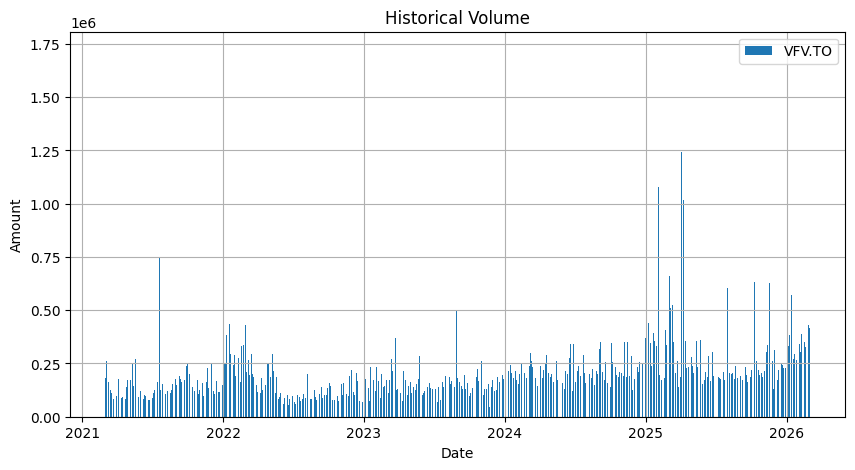

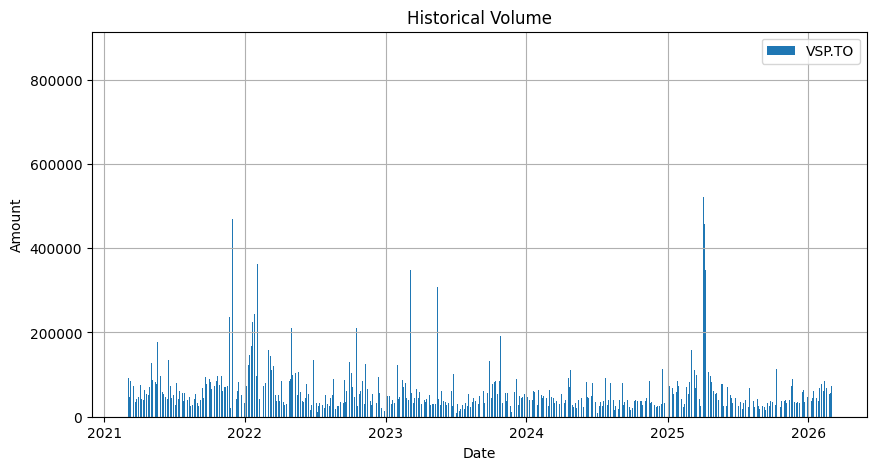

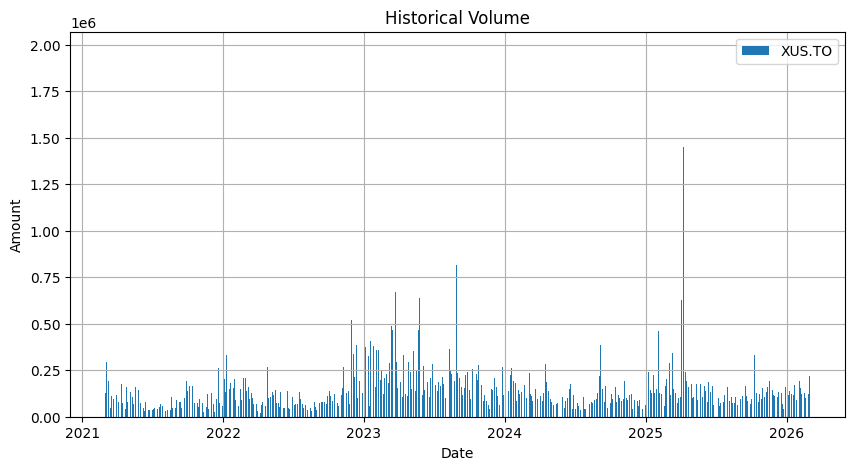

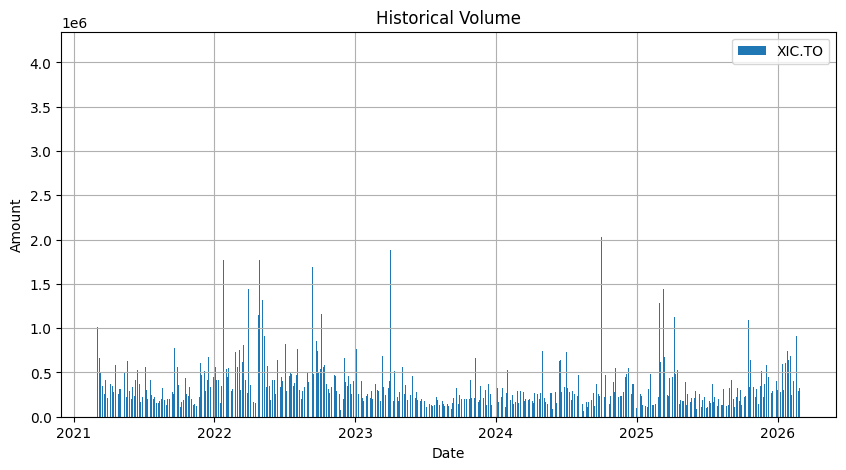

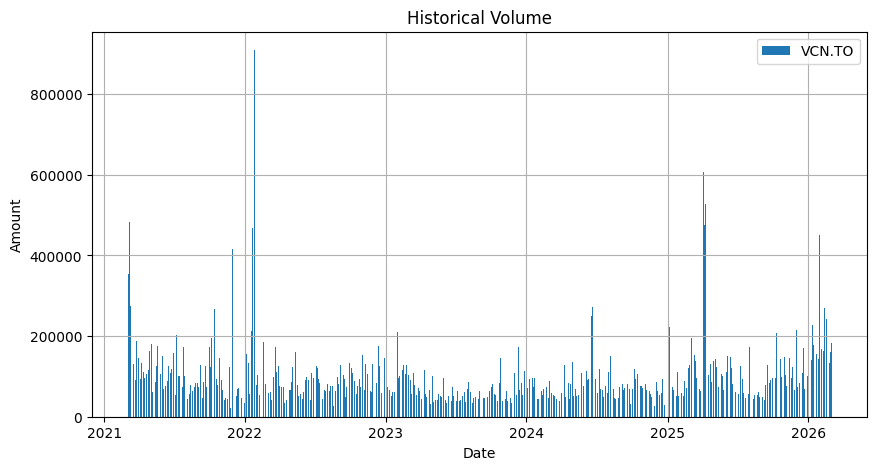

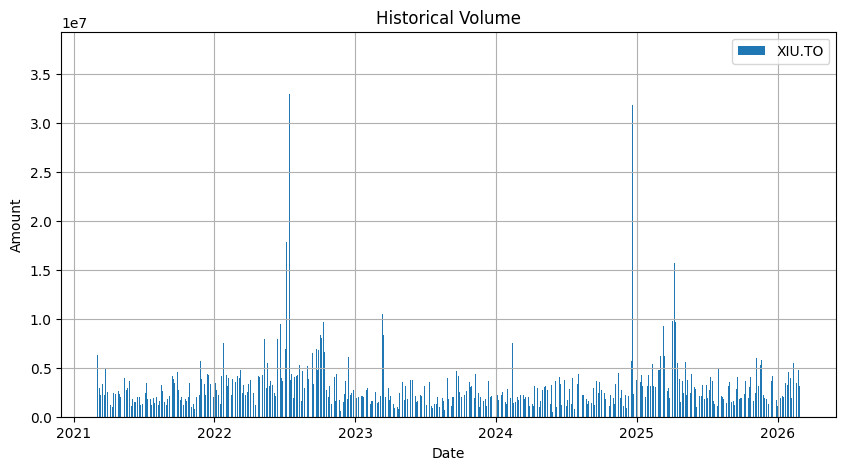

In [45]:

for ticker, df in data.items():
    figure, axis = plt.subplots(figsize=(10, 5))
    axis.bar(df.index, df["Volume"], label=ticker)
    axis.set_title("Historical Volume")
    axis.set_xlabel("Date")
    axis.set_ylabel("Amount")
    axis.legend() 
    axis.grid(True)
plt.show()

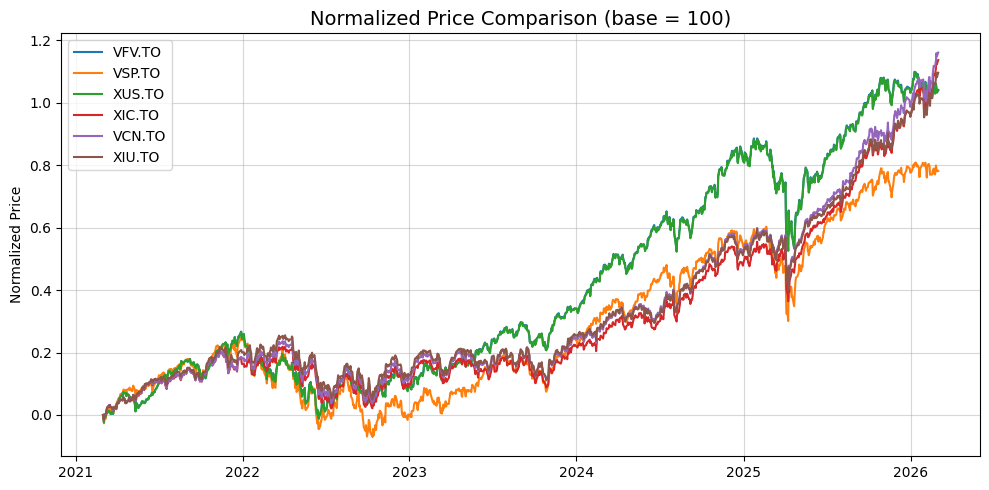

In [48]:
figure, axis = plt.subplots(figsize=(10, 5))
for ticker, df in data.items():
    close_prices = df["Close"]
    normalized_close_prices = (close_prices / close_prices.iloc[0]) - 1
    axis.plot(df.index, normalized_close_prices, label=ticker)
axis.set_title("Normalized Price Comparison (base = 100)", fontsize=14)
axis.set_ylabel("Normalized Price")
axis.legend()
axis.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [51]:
DATA_DIR = os.path.join(os.getcwd(), "data")
os.makedirs(DATA_DIR, exist_ok=True)
for ticker, df in data.items():
    filename = os.path.join(DATA_DIR, f"{ticker.replace('.', '_')}.csv")
    df.to_csv(filename)
    print(f"Saved {filename} ({len(data[ticker])} rows)")

print("\nDone! Data is ready for notebook 02.")

Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VFV_TO.csv (1255 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VSP_TO.csv (1255 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XUS_TO.csv (1255 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XIC_TO.csv (1255 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VCN_TO.csv (1255 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XIU_TO.csv (1255 rows)

Done! Data is ready for notebook 02.
